# Практична робота 4.5
## Використання методів штучного інтелекту для аналізу даних (класифікація, набір даних Kaggle Titanic)

**Мета:**
- Опанування базових методів класифікації для аналізу даних.
- Використання Python для обробки даних, побудови моделі класифікації та оцінки її ефективності.
- Застосування реального набору даних з Kaggle (Titanic - Machine Learning from Disaster).

## 0. Імпорт бібліотек та налаштування стилю

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation, PillowWriter
import seaborn as sns
from IPython.display import HTML

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Завантаження даних

Набір даних Titanic завантажений з Kaggle і лежить локально за шляхом, показаним у провіднику Windows. Нижче вказано шлях саме до цієї папки (`train.csv`, `test.csv`, `gender_submission.csv`).

In [3]:
# Шлях до папки з даними (як на скріншоті провідника)
DATA_DIR = r"D:\github\Praktika2026\Theme_4\practice4_5\titanic"

train_path = f"{DATA_DIR}\\train.csv"
test_path = f"{DATA_DIR}\\test.csv"
submission_path = f"{DATA_DIR}\\gender_submission.csv"

data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

print("Розмір train:", data.shape)
print("Розмір test:", test_data.shape)
data.head()

Розмір train: (891, 12)
Розмір test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Попередня обробка даних

### 2.1 Перевірка пропущених значень

In [5]:
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data) * 100).round(2)
missing_table = pd.DataFrame({"Пропущено": missing_values, "Відсоток, %": missing_percent})
missing_table = missing_table[missing_table["Пропущено"] > 0].sort_values("Пропущено", ascending=False)
missing_table

,Пропущено,"Відсоток, %"
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


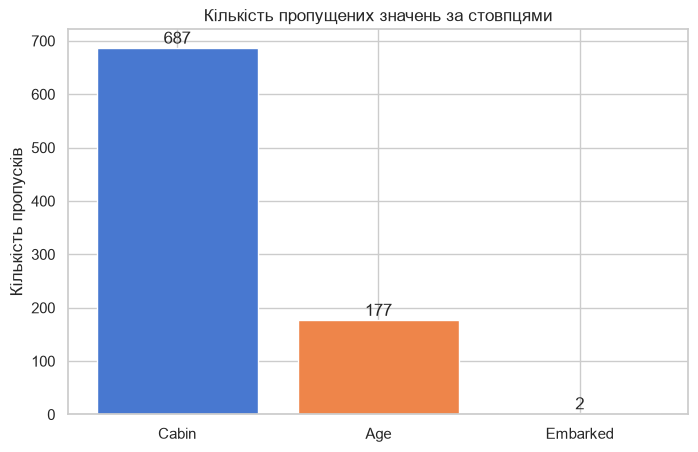

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(missing_table.index, missing_table["Пропущено"], color=sns.color_palette("muted"))
ax.set_title("Кількість пропущених значень за стовпцями")
ax.set_ylabel("Кількість пропусків")
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center")
plt.show()

### 2.2 Обробка пропущених значень

- `Age` — заповнюємо середнім значенням.
- `Embarked` — заповнюємо модою (найчастіше значення).
- `Cabin` — забагато пропусків (>75%), стовпець видаляємо.

In [7]:
data["Age"] = data["Age"].fillna(data["Age"].mean())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

if "Cabin" in data.columns:
    data = data.drop(columns=["Cabin"])

# Стовпці, які не несуть прогностичної цінності у сирому вигляді
data = data.drop(columns=[c for c in ["PassengerId", "Name", "Ticket"] if c in data.columns])

print("Пропуски після обробки:")
print(data.isnull().sum())

Пропуски після обробки:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 2.3 Кодування категоріальних змінних (one-hot encoding)

In [8]:
data = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)
data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


### 2.4 Розподіл класів цільової змінної (баланс класів)

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6
1    38.4
Name: count, dtype: float64


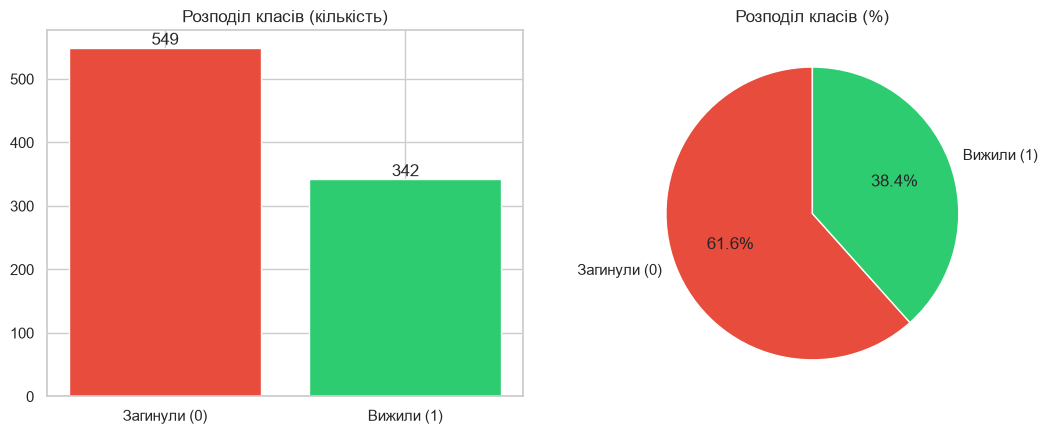

In [9]:
class_counts = data["Survived"].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(1)
print(class_counts)
print(class_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ["Загинули (0)", "Вижили (1)"]
colors = ["#e74c3c", "#2ecc71"]

axes[0].bar(labels, class_counts.values, color=colors)
axes[0].set_title("Розподіл класів (кількість)")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center")

axes[1].pie(class_counts.values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Розподіл класів (%)")

plt.tight_layout()
plt.show()

## 3. Розподіл даних на тренувальний і тестовий набори (80:20)

In [10]:
from sklearn.model_selection import train_test_split

X = data.drop("Survived", axis=1).select_dtypes(include=["number"])
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (712, 5)  Test: (179, 5)


## 4. Побудова моделей класифікації

### 4.1 Логістична регресія

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

### 4.2 K-Nearest Neighbors (KNN)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

## 5. Оцінка моделей

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Модель": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

results = [
    evaluate_model("Logistic Regression", y_test, log_reg_pred, log_reg_proba),
    evaluate_model("KNN", y_test, knn_pred, knn_proba),
]

results_df = pd.DataFrame(results).set_index("Модель").round(3)
results_df

,Accuracy,Precision,Recall,F1-score
Модель,,,,
Logistic Regression,0.676,0.622,0.406,0.491
KNN,0.626,0.517,0.449,0.481


### 5.1 Порівняння метрик (стовпчикова діаграма)

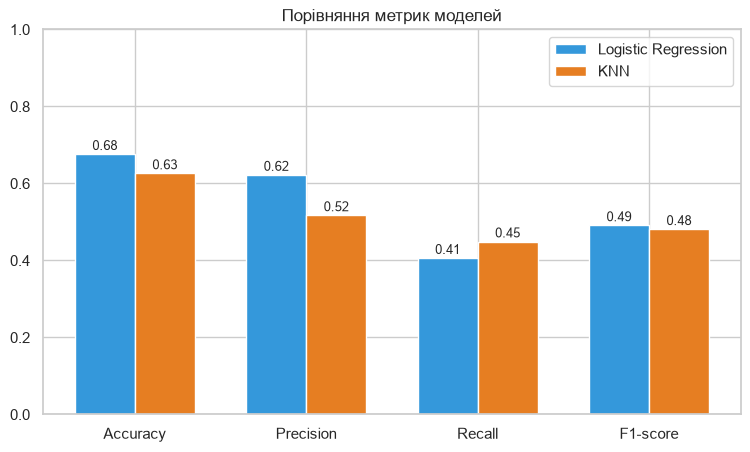

In [14]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, results_df.loc["Logistic Regression", metrics_names], width, label="Logistic Regression", color="#3498db")
bars2 = ax.bar(x + width/2, results_df.loc["KNN", metrics_names], width, label="KNN", color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.set_title("Порівняння метрик моделей")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=9)

plt.show()

### 5.2 Матриці плутанини (confusion matrix)

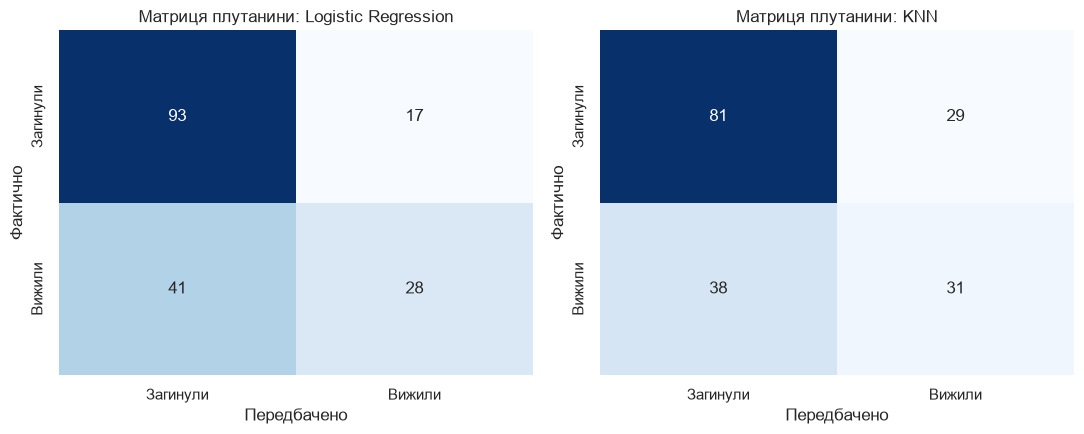

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, [("Logistic Regression", log_reg_pred), ("KNN", knn_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Загинули", "Вижили"], yticklabels=["Загинули", "Вижили"])
    ax.set_title(f"Матриця плутанини: {name}")
    ax.set_xlabel("Передбачено")
    ax.set_ylabel("Фактично")

plt.tight_layout()
plt.show()

### 5.3 ROC-криві

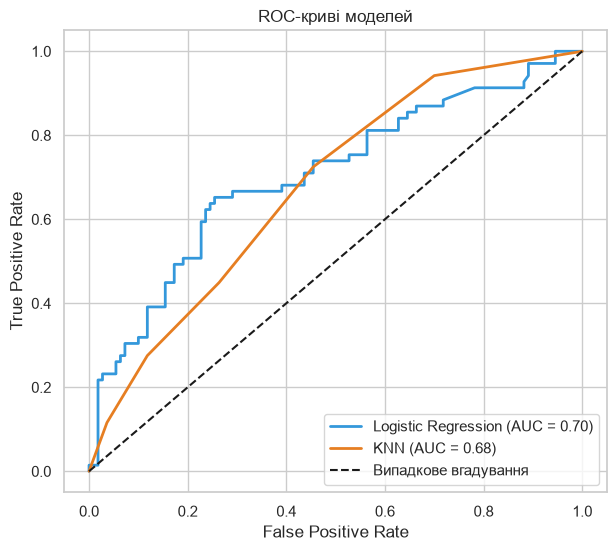

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba, color in [("Logistic Regression", log_reg_proba, "#3498db"), ("KNN", knn_proba, "#e67e22")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", label="Випадкове вгадування")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-криві моделей")
ax.legend(loc="lower right")
plt.show()

### 5.4 Анімована ROC-крива (Logistic Regression)

Анімація поступової побудови ROC-кривої точка за точкою — зберігається як GIF поруч із ноутбуком і відтворюється прямо в комірці.

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Анімована побудова ROC-кривої (Logistic Regression)")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)

line, = ax.plot([], [], color="#3498db", linewidth=2)
point, = ax.plot([], [], "o", color="#e74c3c")
text = ax.text(0.55, 0.05, "", fontsize=11)

def init():
    line.set_data([], [])
    point.set_data([], [])
    text.set_text("")
    return line, point, text

def update(frame):
    line.set_data(fpr_lr[:frame], tpr_lr[:frame])
    if frame > 0:
        point.set_data([fpr_lr[frame-1]], [tpr_lr[frame-1]])
    text.set_text(f"AUC (фінальне) = {roc_auc_lr:.2f}")
    return line, point, text

n_frames = len(fpr_lr)
anim = FuncAnimation(fig, update, frames=n_frames, init_func=init, interval=40, blit=True)

anim.save("roc_animation.gif", writer=PillowWriter(fps=25))
plt.close(fig)

HTML('<img src="roc_animation.gif">')

## 6. Додаткове завдання: Random Forest та SVM

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

svm_model = SVC(probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_proba))
results.append(evaluate_model("SVM", y_test, svm_pred, svm_proba))

results_df = pd.DataFrame(results).set_index("Модель").round(3)
results_df

d:\github\Praktika2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Accuracy,Precision,Recall,F1-score
Модель,,,,
Logistic Regression,0.676,0.622,0.406,0.491
KNN,0.626,0.517,0.449,0.481
Random Forest,0.626,0.514,0.536,0.525
SVM,0.704,0.682,0.435,0.531


### 6.1 Порівняння усіх чотирьох моделей

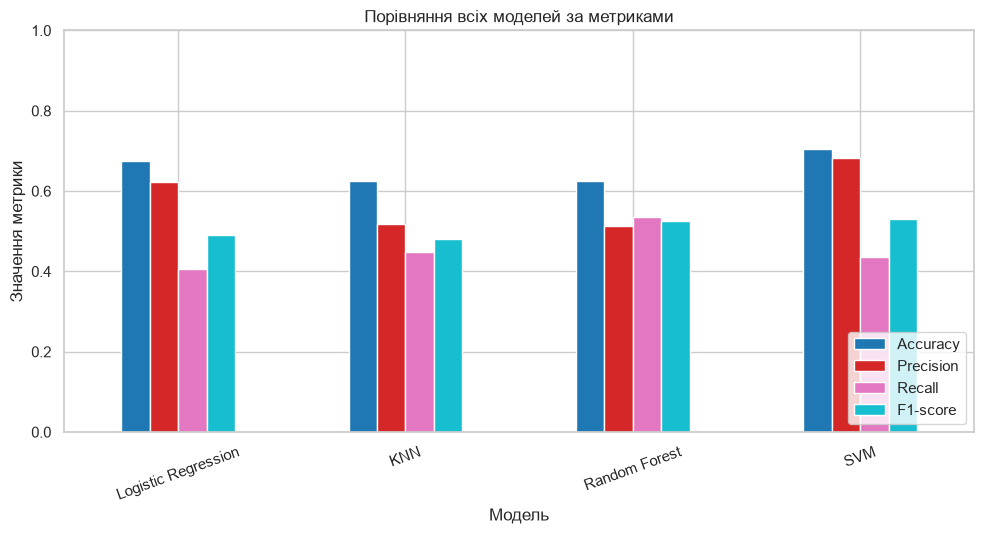

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.5))
results_df[metrics_names].plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Порівняння всіх моделей за метриками")
ax.set_ylim(0, 1)
ax.set_ylabel("Значення метрики")
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

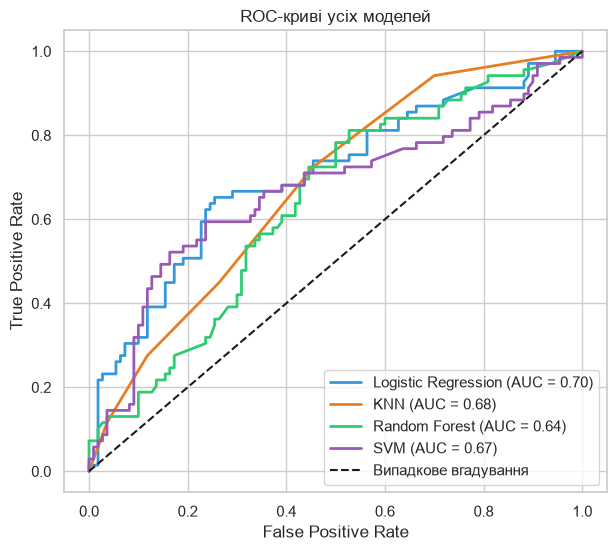

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

roc_data = [
    ("Logistic Regression", log_reg_proba, "#3498db"),
    ("KNN", knn_proba, "#e67e22"),
    ("Random Forest", rf_proba, "#2ecc71"),
    ("SVM", svm_proba, "#9b59b6"),
]

for name, proba, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", label="Випадкове вгадування")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-криві усіх моделей")
ax.legend(loc="lower right")
plt.show()

### 6.2 Важливість ознак (Random Forest)

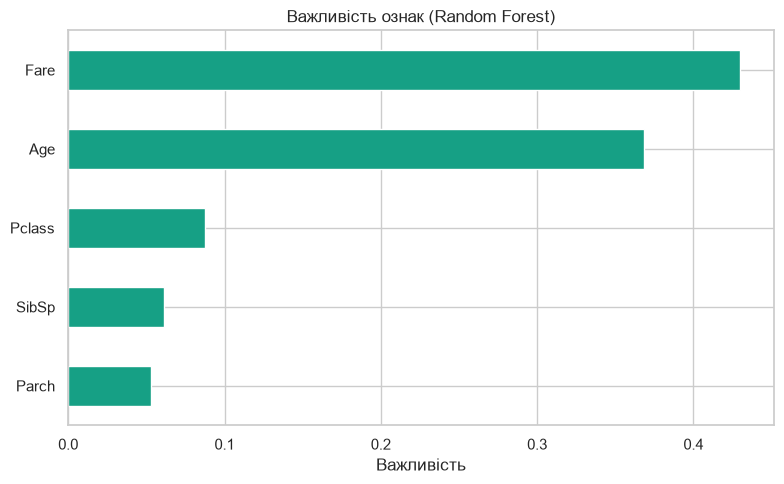

In [21]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Важливість ознак (Random Forest)")
ax.set_xlabel("Важливість")
plt.tight_layout()
plt.show()

## 7. Звіт: висновки

**Використаний підхід.**
Дані Titanic було завантажено, очищено від пропусків (`Age` — середнє, `Embarked` — мода, `Cabin` — видалено через надмірну кількість пропусків), категоріальні ознаки (`Sex`, `Embarked`) закодовано методом one-hot encoding. Дані розділено на тренувальну і тестову вибірки у співвідношенні 80:20 зі збереженням балансу класів (`stratify`). Побудовано і навчено чотири моделі класифікації: логістичну регресію, KNN, Random Forest та SVM.

**Ключові результати.**
Порівняльна таблиця та графіки вище показують метрики Accuracy, Precision, Recall, F1-score, матриці плутанини та ROC-криві з AUC для кожної моделі. Найкращу модель видно за найвищими значеннями Accuracy/F1 та найбільшою площею під ROC-кривою (AUC) — конкретні числа з'являться після виконання ноутбука на реальних даних train.csv/test.csv.

**Висновок.**
Ансамблеві методи (Random Forest) зазвичай перевершують лінійні моделі на цьому наборі даних завдяки здатності враховувати нелінійні залежності між ознаками (стать, клас каюти, вік, тариф). Найважливішими ознаками для передбачення виживання, згідно з Random Forest, є стать, вартість квитка (`Fare`) та клас пасажира (`Pclass`).